# 🤖 VoltVision — Model Training

Now our EV dataset is clean, engineered, fully numerical, and aligned between train and Kaggle test. 🤖

In this notebook we will move in a **learning progression** instead of jumping directly to the strongest boosting model:

**Dummy → Logistic Regression → Decision Tree → Bagging → Boosting → Cross Validation → Tuning → Blending → Final Kaggle Submission**

🎯 **Primary metric:** ROC-AUC  
The target is imbalanced (`Will_Buy_EV = 1` is the minority class), so accuracy alone is not enough. We will also watch **Precision, Recall, and F1**, but ROC-AUC remains the main competition metric.

The raw preprocessing logic will **not** be repeated here. Notebook 02 already prepared the final 25-feature model matrix.

## Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import time
import warnings
import optuna

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42

In [2]:
# Keep FAST_MODE = False for the real competition run.
# Set it to True only when you want a quick local smoke test.
FAST_MODE = False
RUN_CV = True
RUN_TUNING = True

CV_FOLDS = 2 if FAST_MODE else 3
N_TRIALS = 2 if FAST_MODE else 20

processed_path = Path("../data/processed")

X = pd.read_csv(processed_path / "X_train.csv")
y = pd.read_csv(processed_path / "y_train.csv").squeeze("columns")
X_kaggle = pd.read_csv(processed_path / "X_test.csv")
test_ids = pd.read_csv(processed_path / "test_ids.csv").squeeze("columns")

if FAST_MODE:
    X, _, y, _ = train_test_split(
        X,
        y,
        train_size=100000,
        stratify=y,
        random_state=RANDOM_STATE
    )

X.shape, y.shape, X_kaggle.shape, test_ids.shape

((668665, 25), (668665,), (286571, 25), (286571,))

In [3]:
print("Training rows:", len(X))
print("Kaggle test rows:", len(X_kaggle))
print("Features:", X.shape[1])
print("Train missing values:", X.isnull().sum().sum())
print("Test missing values:", X_kaggle.isnull().sum().sum())
print("Train/Test columns identical:", X.columns.equals(X_kaggle.columns))
print("Positive class rate:", round(y.mean() * 100, 2), "%")
print("All model features numerical:", len(X.select_dtypes(exclude=np.number).columns) == 0)

Training rows: 668665
Kaggle test rows: 286571
Features: 25
Train missing values: 0
Test missing values: 0
Train/Test columns identical: True
Positive class rate: 17.46 %
All model features numerical: True


Good — Notebook 02 handed us exactly the model-ready data we expected. ✅

The processed train and Kaggle test matrices have the same columns, contain no missing values, and are fully numerical. We can now focus entirely on **validation and model quality** without touching the feature-engineering logic again.

## Train-Validation Split

In [4]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((534932, 25), (133733, 25), (534932,), (133733,))

In [5]:
print("Train positive rate:", round(y_train.mean() * 100, 2), "%")
print("Validation positive rate:", round(y_valid.mean() * 100, 2), "%")

Train positive rate: 17.46 %
Validation positive rate: 17.46 %


Nice — the stratified split preserves the EV-buyer rate in both sets. That matters because only about one-sixth of the rows belong to the positive class.

We are **not** using SMOTE or random oversampling here. For this competition the main target is probability ranking through ROC-AUC, so preserving the original distribution gives us a cleaner benchmark.

In [6]:
results = []
prediction_store = {}
model_store = {}

def evaluate_model(name, model, X_eval, y_eval, training_time):
    pred = model.predict(X_eval)
    prob = model.predict_proba(X_eval)[:, 1]

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred),
        "F1": f1_score(y_eval, pred),
        "ROC-AUC": roc_auc_score(y_eval, prob),
        "Train_Time_sec": training_time
    }

    results.append(row)
    prediction_store[name] = prob
    model_store[name] = model

    return pred, prob

## Dummy Baseline

In [7]:
start = time.time()

dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(X_train, y_train)

dummy_pred, dummy_prob = evaluate_model(
    "Dummy",
    dummy_model,
    X_valid,
    y_valid,
    time.time() - start
)

In [8]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train_Time_sec
0,Dummy,0.8254,0.0,0.0,0.0,0.5,0.0629


The Dummy model is our floor. Its ROC-AUC should sit around **0.50**, which is what we expect from a model that has no real ranking ability.

Every useful model from this point onward needs to beat that benchmark by a large margin.

## Logistic Regression

In [9]:
start = time.time()

log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

log_model.fit(X_train, y_train)

log_pred, log_prob = evaluate_model(
    "Logistic Regression",
    log_model,
    X_valid,
    y_valid,
    time.time() - start
)

In [10]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train_Time_sec
0,Dummy,0.8254,0.000,0.0000,0.000,0.5000,0.0629
1,Logistic Regression,0.8949,0.717,0.6576,0.686,0.9381,0.8972


Logistic Regression gives us the first real linear benchmark.

Because the feature matrix contains variables on very different numerical scales, scaling is used **only inside this linear model**. Tree-based models below do not need it.

## Decision Tree

In [11]:
start = time.time()

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=30,
    random_state=RANDOM_STATE
)

dt_model.fit(X_train, y_train)

dt_pred, dt_prob = evaluate_model(
    "Decision Tree",
    dt_model,
    X_valid,
    y_valid,
    time.time() - start
)

In [12]:
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train_Time_sec
0,Dummy,0.8254,0.0000,0.0000,0.0000,0.5000,0.0629
1,Logistic Regression,0.8949,0.7170,0.6576,0.6860,0.9381,0.8972
2,Decision Tree,0.8964,0.7188,0.6684,0.6927,0.9375,2.4982


The single tree is useful because it tells us how much nonlinear signal exists before we start using ensembles.

The depth and leaf-size limits are intentional — an unrestricted tree on more than half a million training rows can memorize noise very easily.

## Bagging Models

In [13]:
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=80 if FAST_MODE else 180,
    max_depth=18,
    min_samples_leaf=4,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_model.fit(X_train, y_train)

rf_pred, rf_prob = evaluate_model(
    "Random Forest",
    rf_model,
    X_valid,
    y_valid,
    time.time() - start
)

In [14]:
start = time.time()

et_model = ExtraTreesClassifier(
    n_estimators=100 if FAST_MODE else 220,
    max_depth=20,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

et_model.fit(X_train, y_train)

et_pred, et_prob = evaluate_model(
    "Extra Trees",
    et_model,
    X_valid,
    y_valid,
    time.time() - start
)

In [15]:
pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train_Time_sec
3,Random Forest,0.8977,0.7263,0.6650,0.6943,0.9399,15.7155
4,Extra Trees,0.8963,0.7244,0.6560,0.6885,0.9388,15.1870
1,Logistic Regression,0.8949,0.7170,0.6576,0.6860,0.9381,0.8972
2,Decision Tree,0.8964,0.7188,0.6684,0.6927,0.9375,2.4982
0,Dummy,0.8254,0.0000,0.0000,0.0000,0.5000,0.0629


Now we can see whether averaging many randomized trees improves over the single-tree benchmark.

Random Forest and Extra Trees are strong general-purpose baselines, but on structured tabular data we usually expect the boosting family to become more competitive next.

## Boosting Models

In [16]:
start = time.time()

hist_model = HistGradientBoostingClassifier(
    max_iter=180 if FAST_MODE else 350,
    learning_rate=0.06,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=0.2,
    random_state=RANDOM_STATE
)

hist_model.fit(X_train, y_train)

hist_pred, hist_prob = evaluate_model(
    "HistGradientBoosting",
    hist_model,
    X_valid,
    y_valid,
    time.time() - start
)

In [17]:
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=450 if FAST_MODE else 1200,
    learning_rate=0.04,
    max_depth=6,
    min_child_weight=3,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.0,
    reg_lambda=1.0,
    eval_metric="auc",
    tree_method="hist",
    early_stopping_rounds=80,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

xgb_pred, xgb_prob = evaluate_model(
    "XGBoost",
    xgb_model,
    X_valid,
    y_valid,
    time.time() - start
)

In [18]:
start = time.time()

lgb_model = LGBMClassifier(
    n_estimators=500 if FAST_MODE else 1500,
    learning_rate=0.035,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.0,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(80, verbose=False)]
)

lgb_pred, lgb_prob = evaluate_model(
    "LightGBM",
    lgb_model,
    X_valid,
    y_valid,
    time.time() - start
)

In [19]:
start = time.time()

cat_model = CatBoostClassifier(
    iterations=550 if FAST_MODE else 1300,
    learning_rate=0.04,
    depth=7,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    thread_count=-1,
    verbose=False,
    allow_writing_files=False
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=80,
    verbose=False
)

cat_pred, cat_prob = evaluate_model(
    "CatBoost",
    cat_model,
    X_valid,
    y_valid,
    time.time() - start
)

In [20]:
pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train_Time_sec
7,LightGBM,0.8985,0.7253,0.6741,0.6988,0.9419,6.3208
6,XGBoost,0.8983,0.7254,0.6724,0.6979,0.9418,17.6471
8,CatBoost,0.8987,0.7266,0.6728,0.6987,0.9416,29.4160
5,HistGradientBoosting,0.8982,0.7263,0.6692,0.6966,0.9414,5.9502
3,Random Forest,0.8977,0.7263,0.6650,0.6943,0.9399,15.7155
4,Extra Trees,0.8963,0.7244,0.6560,0.6885,0.9388,15.1870
1,Logistic Regression,0.8949,0.7170,0.6576,0.6860,0.9381,0.8972
2,Decision Tree,0.8964,0.7188,0.6684,0.6927,0.9375,2.4982
0,Dummy,0.8254,0.0000,0.0000,0.0000,0.5000,0.0629


This is the most important first comparison. 🔎

The three modern boosting libraries — **XGBoost, LightGBM, and CatBoost** — are the serious competition candidates. Early stopping lets each one stop when validation AUC no longer improves instead of forcing every boosting round.

We will use the results above to decide how much effort is worth spending on validation and tuning.

## Model Comparison

In [21]:
results_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train_Time_sec
0,LightGBM,0.8985,0.7253,0.6741,0.6988,0.9419,6.3208
1,XGBoost,0.8983,0.7254,0.6724,0.6979,0.9418,17.6471
2,CatBoost,0.8987,0.7266,0.6728,0.6987,0.9416,29.4160
3,HistGradientBoosting,0.8982,0.7263,0.6692,0.6966,0.9414,5.9502
4,Random Forest,0.8977,0.7263,0.6650,0.6943,0.9399,15.7155
5,Extra Trees,0.8963,0.7244,0.6560,0.6885,0.9388,15.1870
6,Logistic Regression,0.8949,0.7170,0.6576,0.6860,0.9381,0.8972
7,Decision Tree,0.8964,0.7188,0.6684,0.6927,0.9375,2.4982
8,Dummy,0.8254,0.0000,0.0000,0.0000,0.5000,0.0629


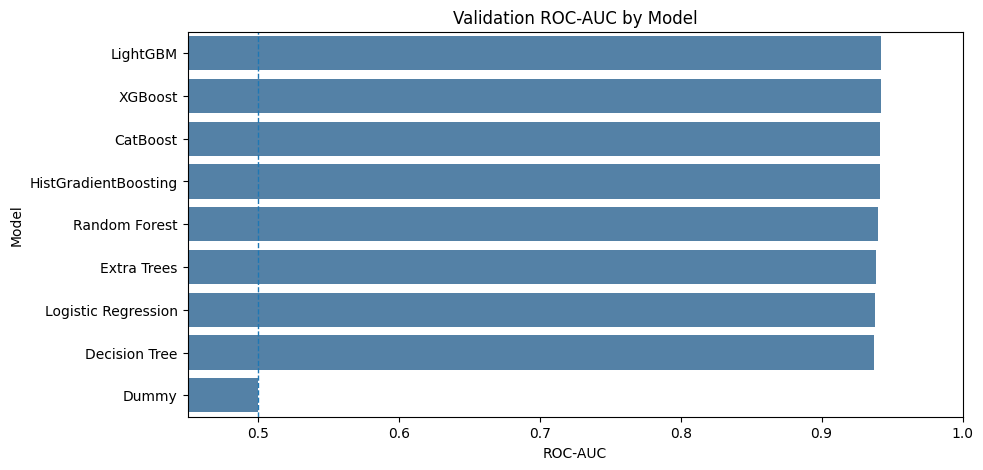

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="ROC-AUC",
    y="Model",
    color="steelblue"
)

plt.axvline(0.50, linestyle="--", linewidth=1)
plt.title("Validation ROC-AUC by Model")
plt.xlim(0.45, 1.0)
plt.show()

The ranking above gives us a clean separation between **baseline models** and the models worth carrying forward.

From here we stop spending compute on every algorithm. Cross-validation and tuning will focus on the strongest boosting family, which is the right trade-off for a dataset this large.

## Cross Validation

In [23]:
def safe_best_rounds(model, default_rounds):
    if hasattr(model, "best_iteration_") and model.best_iteration_:
        return int(model.best_iteration_)
    if hasattr(model, "best_iteration") and model.best_iteration is not None:
        return int(model.best_iteration) + 1
    if hasattr(model, "get_best_iteration"):
        value = model.get_best_iteration()
        if value is not None and value >= 0:
            return int(value) + 1
    return int(default_rounds)

xgb_rounds = safe_best_rounds(xgb_model, 500)
lgb_rounds = safe_best_rounds(lgb_model, 500)
cat_rounds = safe_best_rounds(cat_model, 700)

print("XGBoost rounds:", xgb_rounds)
print("LightGBM rounds:", lgb_rounds)
print("CatBoost rounds:", cat_rounds)

XGBoost rounds: 744
LightGBM rounds: 667
CatBoost rounds: 1255


In [24]:
if RUN_CV:
    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    cv_templates = {
        "XGBoost": XGBClassifier(
            n_estimators=xgb_rounds,
            learning_rate=0.04,
            max_depth=6,
            min_child_weight=3,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_lambda=1.0,
            eval_metric="auc",
            tree_method="hist",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=lgb_rounds,
            learning_rate=0.035,
            num_leaves=31,
            min_child_samples=30,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_lambda=1.0,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=-1
        ),
        "CatBoost": CatBoostClassifier(
            iterations=cat_rounds,
            learning_rate=0.04,
            depth=7,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            thread_count=-1,
            verbose=False,
            allow_writing_files=False
        )
    }

    cv_rows = []

    for model_name, template in cv_templates.items():
        fold_scores = []

        for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
            fold_model = clone(template)
            fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])

            fold_prob = fold_model.predict_proba(X.iloc[valid_idx])[:, 1]
            fold_auc = roc_auc_score(y.iloc[valid_idx], fold_prob)
            fold_scores.append(fold_auc)

        cv_rows.append({
            "Model": model_name,
            "CV_AUC_Mean": np.mean(fold_scores),
            "CV_AUC_Std": np.std(fold_scores),
            "Folds": CV_FOLDS
        })

    cv_results = pd.DataFrame(cv_rows).sort_values("CV_AUC_Mean", ascending=False)
else:
    cv_results = pd.DataFrame(columns=["Model", "CV_AUC_Mean", "CV_AUC_Std", "Folds"])

cv_results.round(5)

,Model,CV_AUC_Mean,CV_AUC_Std,Folds
1,LightGBM,0.94188,0.00071,3
0,XGBoost,0.94187,0.00062,3
2,CatBoost,0.94173,0.00062,3


A single holdout split is useful for fast iteration, but cross-validation tells us whether the strongest models remain stable across different parts of the training data.

We use only the **three serious boosting candidates** here. Running cross-validation on every baseline model would add a lot of compute without helping the final decision.

## Hyperparameter Tuning

In [25]:
def objective(trial):
    params = {
        "n_estimators": 700 if FAST_MODE else 1800,
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 80),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 100),
        "subsample": trial.suggest_float("subsample", 0.75, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(70, verbose=False)]
    )

    prob = model.predict_proba(X_valid)[:, 1]
    return roc_auc_score(y_valid, prob)

In [26]:
if RUN_TUNING:
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    print("Best ROC-AUC:", round(study.best_value, 6))
    print("Best parameters:")
    print(study.best_params)
else:
    study = None
    print("Tuning skipped. Base LightGBM will be used as the tuned candidate.")

Best ROC-AUC: 0.942101
Best parameters:
{'learning_rate': 0.044992586271017966, 'num_leaves': 22, 'max_depth': 4, 'min_child_samples': 15, 'subsample': 0.9932053351664416, 'colsample_bytree': 0.815086376920282, 'reg_alpha': 0.0772763202432187, 'reg_lambda': 2.5884583305071853}


In [27]:
if RUN_TUNING:
    tuned_params = study.best_params.copy()

    tuned_lgb_model = LGBMClassifier(
        n_estimators=700 if FAST_MODE else 2000,
        **tuned_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )

    start = time.time()

    tuned_lgb_model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(80, verbose=False)]
    )

    tuned_lgb_pred = tuned_lgb_model.predict(X_valid)
    tuned_lgb_prob = tuned_lgb_model.predict_proba(X_valid)[:, 1]
    tuned_lgb_auc = roc_auc_score(y_valid, tuned_lgb_prob)
    tuned_lgb_time = time.time() - start
else:
    tuned_params = {}
    tuned_lgb_model = lgb_model
    tuned_lgb_pred = lgb_pred
    tuned_lgb_prob = lgb_prob
    tuned_lgb_auc = roc_auc_score(y_valid, lgb_prob)
    tuned_lgb_time = 0.0

print("Base LightGBM AUC:", round(roc_auc_score(y_valid, lgb_prob), 6))
print("Tuned LightGBM AUC:", round(tuned_lgb_auc, 6))
print("Tuned best iteration:", safe_best_rounds(tuned_lgb_model, lgb_rounds))

Base LightGBM AUC: 0.941852
Tuned LightGBM AUC: 0.942101
Tuned best iteration: 1766


The tuning search is intentionally focused on **LightGBM** rather than blindly tuning every model.

It is fast, strong on this type of tabular data, and gives us enough flexibility to test leaf complexity, regularization, sampling, and learning rate. The final decision will still be based on validation performance — tuning is useful only if it actually improves AUC.

## Model Blending

In [28]:
boosting_auc = {
    "XGBoost": roc_auc_score(y_valid, xgb_prob),
    "Tuned LightGBM": tuned_lgb_auc,
    "CatBoost": roc_auc_score(y_valid, cat_prob)
}

boosting_auc

{'XGBoost': 0.9418471373072973,
 'Tuned LightGBM': 0.9421013556330333,
 'CatBoost': 0.9416390189054267}

In [29]:
weight_values = np.arange(0.0, 1.01, 0.10)

best_blend_auc = -np.inf
best_weights = None
best_blend_prob = None

for lgb_weight in weight_values:
    for xgb_weight in weight_values:
        cat_weight = 1.0 - lgb_weight - xgb_weight

        if cat_weight < -1e-9:
            continue

        cat_weight = max(cat_weight, 0.0)

        blend_prob = (
            lgb_weight * tuned_lgb_prob +
            xgb_weight * xgb_prob +
            cat_weight * cat_prob
        )

        blend_auc = roc_auc_score(y_valid, blend_prob)

        if blend_auc > best_blend_auc:
            best_blend_auc = blend_auc
            best_weights = {
                "LightGBM": round(float(lgb_weight), 2),
                "XGBoost": round(float(xgb_weight), 2),
                "CatBoost": round(float(cat_weight), 2)
            }
            best_blend_prob = blend_prob

print("Best blend AUC:", round(best_blend_auc, 6))
print("Best weights:", best_weights)

Best blend AUC: 0.942168
Best weights: {'LightGBM': 0.7, 'XGBoost': 0.2, 'CatBoost': 0.1}


The blend is deliberately simple: we search coarse **0.10 weight steps** across the three strongest boosting models.

This keeps the ensemble understandable and reproducible. If the blend does not beat the best single model, we will not force it into the final solution.

## Final Validation

In [30]:
best_single_name = max(boosting_auc, key=boosting_auc.get)
best_single_auc = boosting_auc[best_single_name]

candidate_probabilities = {
    "XGBoost": xgb_prob,
    "Tuned LightGBM": tuned_lgb_prob,
    "CatBoost": cat_prob,
    "Blend": best_blend_prob
}

candidate_auc = {
    name: roc_auc_score(y_valid, prob)
    for name, prob in candidate_probabilities.items()
}

final_name = max(candidate_auc, key=candidate_auc.get)
final_prob = candidate_probabilities[final_name]
final_pred = (final_prob >= 0.50).astype(int)

print("Best single model:", best_single_name, "| AUC:", round(best_single_auc, 6))
print("Final validation choice:", final_name, "| AUC:", round(candidate_auc[final_name], 6))

Best single model: Tuned LightGBM | AUC: 0.942101
Final validation choice: Blend | AUC: 0.942168


In [31]:
final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Score": [
        accuracy_score(y_valid, final_pred),
        precision_score(y_valid, final_pred, zero_division=0),
        recall_score(y_valid, final_pred),
        f1_score(y_valid, final_pred),
        roc_auc_score(y_valid, final_prob)
    ]
})

final_metrics.round(4)

,Metric,Score
0,Accuracy,0.8987
1,Precision,0.7258
2,Recall,0.6750
3,F1,0.6995
4,ROC-AUC,0.9422


              precision    recall  f1-score   support

           0     0.9322    0.9460    0.9391    110377
           1     0.7258    0.6750    0.6995     23356

    accuracy                         0.8987    133733
   macro avg     0.8290    0.8105    0.8193    133733
weighted avg     0.8962    0.8987    0.8973    133733



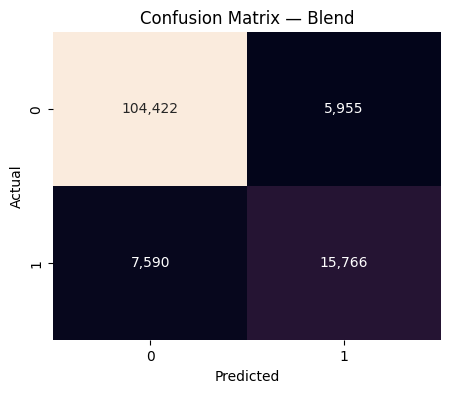

In [32]:
print(classification_report(y_valid, final_pred, digits=4))

cm = confusion_matrix(y_valid, final_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {final_name}")
plt.show()

ROC-AUC is still the main metric, while the threshold-based metrics above are diagnostic.

That distinction matters: Kaggle evaluates the **ranking of probabilities**, not whether we happened to choose the best 0.50 classification threshold.

## ROC Curve

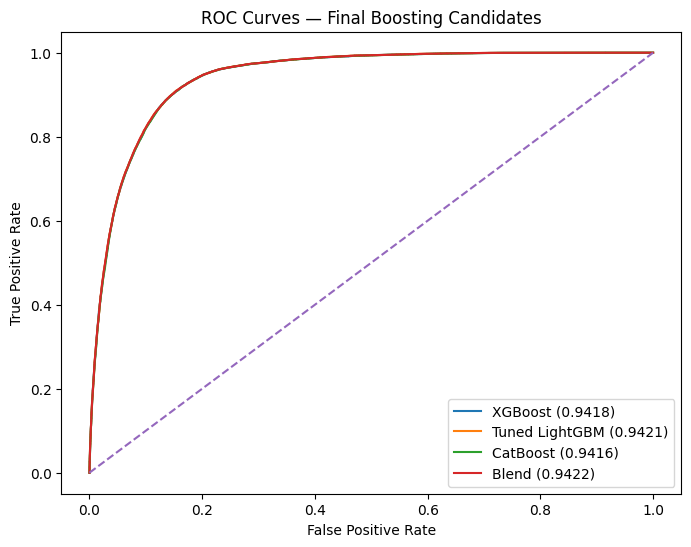

In [33]:
plt.figure(figsize=(8, 6))

roc_candidates = {
    "XGBoost": xgb_prob,
    "Tuned LightGBM": tuned_lgb_prob,
    "CatBoost": cat_prob,
    "Blend": best_blend_prob
}

for name, prob in roc_candidates.items():
    fpr, tpr, _ = roc_curve(y_valid, prob)
    auc = roc_auc_score(y_valid, prob)
    plt.plot(fpr, tpr, label=f"{name} ({auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Final Boosting Candidates")
plt.legend()
plt.show()

## Feature Importance

In [34]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tuned_lgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
2,Daily_Commute_km,3472
1,Annual_Income_USD,3248
16,Income_x_Concern,3132
17,Subsidy_x_Income,2801
0,Age,2640
11,Income_Per_Car,2474
10,Total_Charging_Stations,1666
4,Charging_Stations_Near_Home,1382
5,Charging_Stations_Near_Work,1272
6,Environmental_Concern_Level,510


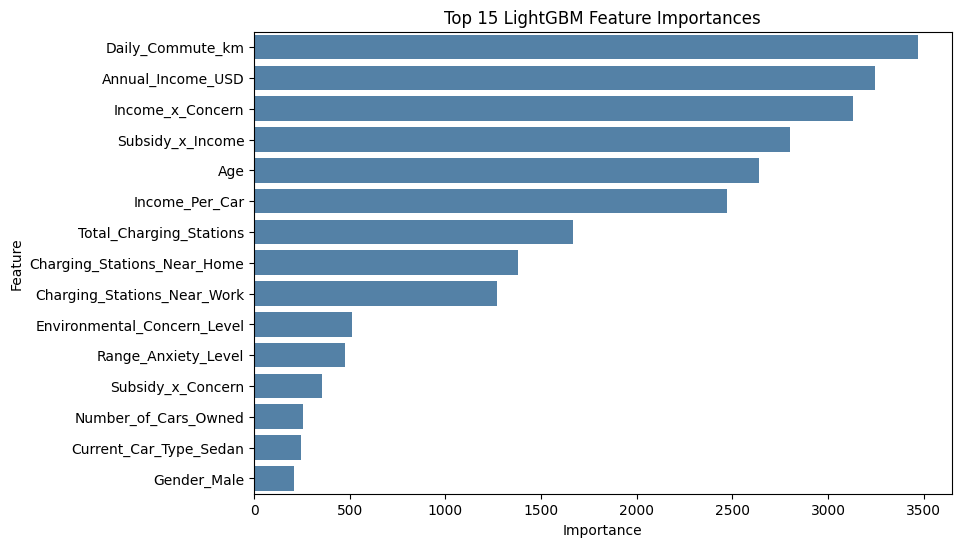

In [35]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature",
    color="steelblue"
)

plt.title("Top 15 LightGBM Feature Importances")
plt.show()

Feature importance is not the same thing as causality, but it is a useful sanity check.

We especially want to see whether the model is using the EV-specific signals discovered during EDA and feature engineering — income, subsidy, environmental concern, range anxiety, charging access, and the interactions built from them.

## Prediction Analysis

In [36]:
pd.Series(final_prob).describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).round(4)

count    133733.0000
mean          0.1754
std           0.2716
min           0.0000
1%            0.0001
5%            0.0002
25%           0.0023
50%           0.0174
75%           0.2706
95%           0.8055
99%           0.8970
max           0.9936
dtype: float64

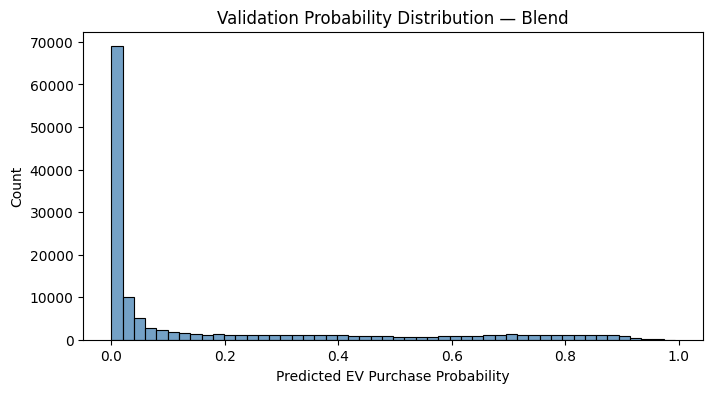

In [37]:
plt.figure(figsize=(8, 4))

sns.histplot(final_prob, bins=50, kde=False, color="steelblue")
plt.xlabel("Predicted EV Purchase Probability")
plt.title(f"Validation Probability Distribution — {final_name}")
plt.show()

This distribution tells us whether the model is producing a healthy range of probabilities instead of collapsing most customers around a single value.

For an ROC-AUC competition, good probability ranking is exactly what we care about.

## Error Analysis

In [38]:
error_df = X_valid.copy()
error_df["Actual"] = y_valid.values
error_df["Probability"] = final_prob
error_df["Predicted"] = final_pred

error_df["Error_Type"] = "Correct"
error_df.loc[(error_df["Actual"] == 0) & (error_df["Predicted"] == 1), "Error_Type"] = "False Positive"
error_df.loc[(error_df["Actual"] == 1) & (error_df["Predicted"] == 0), "Error_Type"] = "False Negative"

error_df["Error_Type"].value_counts()

Error_Type
Correct           120188
False Negative      7590
False Positive      5955
Name: count, dtype: int64

In [39]:
false_negatives = (
    error_df[error_df["Error_Type"] == "False Negative"]
    .sort_values("Probability", ascending=False)
)

false_positives = (
    error_df[error_df["Error_Type"] == "False Positive"]
    .sort_values("Probability", ascending=True)
)

print("Hard false negatives:")
display(false_negatives.head(5))

print("Hard false positives:")
display(false_positives.head(5))

Hard false negatives:


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,...,Gender_Other,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Actual,Probability,Predicted,Error_Type
529079,49,138353.0,5.0,2,3,5,3,1,1,0,...,0,0,1,0,0,0,1,0.499966,0,False Negative
490862,50,102928.0,30.4,1,2,2,4,1,1,0,...,0,0,0,0,0,0,1,0.499960,0,False Negative
471974,61,58922.0,54.5,1,12,16,5,1,1,0,...,0,0,1,1,0,0,1,0.499875,0,False Negative
593799,69,51365.0,42.5,2,7,4,4,1,1,0,...,0,1,0,0,1,0,1,0.499855,0,False Negative
668480,36,116449.0,32.0,2,13,14,4,0,1,0,...,0,0,1,1,0,0,1,0.499844,0,False Negative


Hard false positives:


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,...,Gender_Other,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Actual,Probability,Predicted,Error_Type
339348,47,92626.0,47.5,3,0,1,4,1,1,0,...,0,0,0,0,1,0,0,0.500014,1,False Positive
139214,49,111748.0,13.8,3,9,18,3,0,1,0,...,0,0,1,0,1,0,0,0.500151,1,False Positive
357325,33,96537.0,51.4,1,5,5,4,1,1,0,...,0,1,0,0,0,0,0,0.500188,1,False Positive
60460,44,80141.0,11.1,1,3,7,4,1,1,0,...,0,1,0,0,1,0,0,0.500214,1,False Positive
516047,46,101152.0,5.0,1,1,2,4,1,1,0,...,0,0,0,0,1,0,0,0.500221,1,False Positive


The error table is mainly a diagnostic tool. It helps us inspect the kinds of customers the model finds ambiguous and can expose suspicious feature patterns or opportunities for future feature engineering.

We will **not** redesign the feature space inside this notebook; any new feature idea discovered here belongs in a later experiment, not in the middle of the final training flow.

## Full Dataset Training

In [40]:
final_lgb_rounds = safe_best_rounds(tuned_lgb_model, lgb_rounds)
final_xgb_rounds = safe_best_rounds(xgb_model, xgb_rounds)
final_cat_rounds = safe_best_rounds(cat_model, cat_rounds)

final_lgb_params = tuned_params.copy() if RUN_TUNING else {
    "learning_rate": 0.035,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0
}

final_lgb_model = LGBMClassifier(
    n_estimators=final_lgb_rounds,
    **final_lgb_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

final_xgb_model = XGBClassifier(
    n_estimators=final_xgb_rounds,
    learning_rate=0.04,
    max_depth=6,
    min_child_weight=3,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.0,
    reg_lambda=1.0,
    eval_metric="auc",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

final_cat_model = CatBoostClassifier(
    iterations=final_cat_rounds,
    learning_rate=0.04,
    depth=7,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    thread_count=-1,
    verbose=False,
    allow_writing_files=False
)

final_lgb_model.fit(X, y)
final_xgb_model.fit(X, y, verbose=False)
final_cat_model.fit(X, y, verbose=False)

print("Full-data models trained.")

Full-data models trained.


In [41]:
full_test_prob = {
    "Tuned LightGBM": final_lgb_model.predict_proba(X_kaggle)[:, 1],
    "XGBoost": final_xgb_model.predict_proba(X_kaggle)[:, 1],
    "CatBoost": final_cat_model.predict_proba(X_kaggle)[:, 1]
}

best_single_test_prob = full_test_prob[best_single_name]

blend_test_prob = (
    best_weights["LightGBM"] * full_test_prob["Tuned LightGBM"] +
    best_weights["XGBoost"] * full_test_prob["XGBoost"] +
    best_weights["CatBoost"] * full_test_prob["CatBoost"]
)

print("Best single test probability range:", best_single_test_prob.min(), best_single_test_prob.max())
print("Blend test probability range:", blend_test_prob.min(), blend_test_prob.max())

Best single test probability range: 1.2071025448153924e-06 0.9898919712721009
Blend test probability range: 5.250741731233387e-06 0.9870121291779588


## Kaggle Submission

In [42]:
submission_path = Path("../submissions")
submission_path.mkdir(parents=True, exist_ok=True)

submission_best = pd.DataFrame({
    "id": test_ids,
    "Will_Buy_EV": best_single_test_prob
})

submission_blend = pd.DataFrame({
    "id": test_ids,
    "Will_Buy_EV": blend_test_prob
})

submission_best.to_csv(submission_path / "submission_best_model.csv", index=False)
submission_blend.to_csv(submission_path / "submission_blend.csv", index=False)

submission_best.head()

,id,Will_Buy_EV
0,668665,0.011571
1,668666,0.020660
2,668667,0.005246
3,668668,0.003408
4,668669,0.019802


In [43]:
print("Best-model submission shape:", submission_best.shape)
print("Blend submission shape:", submission_blend.shape)
print("Duplicate IDs:", submission_best["id"].duplicated().sum())
print("Missing best probabilities:", submission_best["Will_Buy_EV"].isnull().sum())
print("Missing blend probabilities:", submission_blend["Will_Buy_EV"].isnull().sum())
print("Best probabilities inside [0,1]:", submission_best["Will_Buy_EV"].between(0, 1).all())
print("Blend probabilities inside [0,1]:", submission_blend["Will_Buy_EV"].between(0, 1).all())

Best-model submission shape: (286571, 2)
Blend submission shape: (286571, 2)
Duplicate IDs: 0
Missing best probabilities: 0
Missing blend probabilities: 0
Best probabilities inside [0,1]: True
Blend probabilities inside [0,1]: True


Great — we now have two Kaggle-ready files:

- `submission_best_model.csv` → strongest individual boosting model
- `submission_blend.csv` → validation-selected weighted blend

Submitting both is useful because a validation improvement does not always translate perfectly to the public leaderboard.

## Save Final Models

In [44]:
models_path = Path("../models")
models_path.mkdir(parents=True, exist_ok=True)

joblib.dump(final_lgb_model, models_path / "lightgbm_final.pkl")
joblib.dump(final_xgb_model, models_path / "xgboost_final.pkl")
joblib.dump(final_cat_model, models_path / "catboost_final.pkl")

metadata = {
    "random_state": RANDOM_STATE,
    "features": list(X.columns),
    "best_single_model": best_single_name,
    "validation_auc": {k: float(v) for k, v in candidate_auc.items()},
    "blend_weights": best_weights,
    "lightgbm_rounds": int(final_lgb_rounds),
    "xgboost_rounds": int(final_xgb_rounds),
    "catboost_rounds": int(final_cat_rounds),
    "lightgbm_tuned_params": tuned_params
}

with open(models_path / "training_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

list(models_path.iterdir())

[WindowsPath('../models/catboost_final.pkl'),
 WindowsPath('../models/lightgbm_final.pkl'),
 WindowsPath('../models/training_metadata.json'),
 WindowsPath('../models/xgboost_final.pkl')]

## Model Training Summary

| Stage | Status |
|---|:---:|
| Processed Feature Engineering outputs loaded | ✅ |
| Stratified train/validation split | ✅ |
| Dummy baseline | ✅ |
| Logistic Regression | ✅ |
| Decision Tree | ✅ |
| Random Forest / Extra Trees | ✅ |
| HistGradientBoosting | ✅ |
| XGBoost | ✅ |
| LightGBM | ✅ |
| CatBoost | ✅ |
| ROC-AUC model comparison | ✅ |
| Boosting cross-validation | ✅ |
| Optuna LightGBM tuning | ✅ |
| Validation-based blending | ✅ |
| Final ROC / feature importance / error analysis | ✅ |
| Full-data retraining | ✅ |
| Best-model Kaggle submission | ✅ |
| Blend Kaggle submission | ✅ |
| Final models + metadata saved | ✅ |

Notebook 03 completes the main VoltVision modeling pipeline. ⚡

The important rule now is simple: **trust validation first, then use the Kaggle leaderboard as an external benchmark — not as a replacement for validation.**